In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from statsmodels.nonparametric.smoothers_lowess import lowess

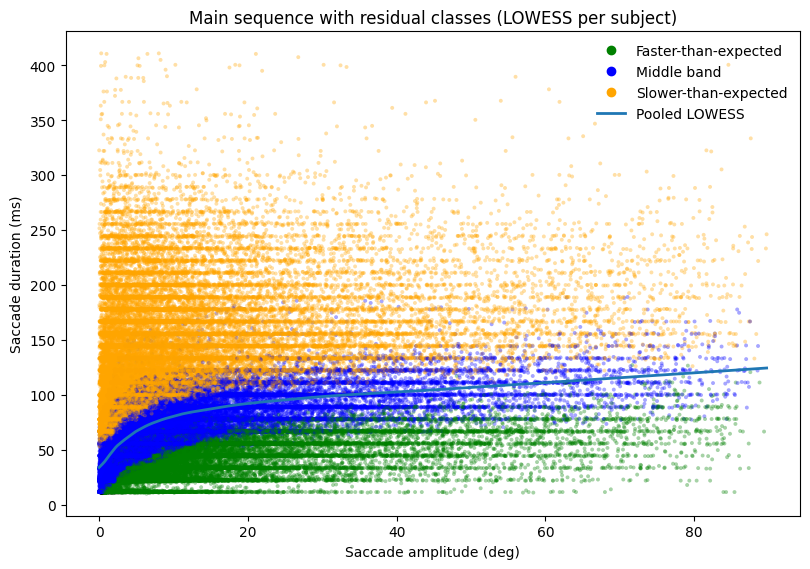

In [2]:
# ----------------- Config -----------------
CSV   = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe.csv"

SUBJ  = "SubjectID"
SESS  = "Session"
TIME  = "total_time"
EVENT = "events"                   #  1 = saccade onset, -1 = saccade end; 2 = fixation start, -2 = fixation end
AMP   = "saccade_amplitude_deg"    #  deg
LEN   = "length"                   #  seconds (on saccade ONSET row)

# Residual-classification params
LOWESS_FRAC = 0.20
K_MAD       = 1.00  # threshold = K_MAD * MAD

# Legend labels
LBL_FAST = "Faster-than-expected"
LBL_MID  = "Middle band"
LBL_SLOW = "Slower-than-expected"

# ----------------- Load -----------------
df = pd.read_csv(CSV)
for c in [SUBJ, SESS, TIME, EVENT, AMP, LEN, "combinedGazeValidityBitmask", "long_events"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
df.sort_values([SUBJ, SESS, TIME], inplace=True, kind="mergesort")
df.reset_index(drop=True, inplace=True)

# ----------------- Valid onset mask (robust to missing columns) -----------------
valid_mask = (df[EVENT] == 1.0) & df[AMP].notna() & df[LEN].notna()
valid_mask &= (df["combinedGazeValidityBitmask"] == 3)
valid_mask &= df["long_events"].notna()

# Ensure output columns exist (final names only)
for col in ["PredictedAmpDur", "ResidualAmpDur", "ResidualClassAmpDur"]:
    if col not in df.columns:
        df[col] = np.nan

# ----------------- Per-subject LOWESS, residuals, MAD thresholding -----------------
for sid, dsub in df.loc[valid_mask].groupby(SUBJ, sort=False):
    a = dsub[AMP].to_numpy()
    y = (dsub[LEN].to_numpy() * 1000.0)  # ms

    # LOWESS fit: predict duration from amplitude
    lo = lowess(endog=y, exog=a, frac=LOWESS_FRAC, return_sorted=True, it=1)
    xg, yg = lo[:, 0], lo[:, 1]
    pred = np.interp(a, xg, yg)

    resid = y - pred                                   # ms residual (observed - predicted)
    mad   = np.median(np.abs(resid - np.median(resid)))
    thr   = K_MAD * mad

    # Classify residuals: -1 shorter/faster, 0 middle, +1 longer/slower
    cls = np.where(resid <= -thr, -1, np.where(resid >=  thr, +1, 0))

    # Write back (final columns only)
    df.loc[dsub.index, "PredictedAmpDur"]      = pred
    df.loc[dsub.index, "ResidualAmpDur"]       = resid
    df.loc[dsub.index, "ResidualClassAmpDur"]  = cls

# ----------------- Plot: pooled main sequence colored by residual class -----------------
plot_mask = valid_mask.copy()
amp = df.loc[plot_mask, AMP].to_numpy()
dur = (df.loc[plot_mask, LEN].to_numpy() * 1000.0)
cls = df.loc[plot_mask, "ResidualClassAmpDur"].to_numpy()

# Pooled LOWESS (reference)
xgrid_pooled = np.array([])
ygrid_pooled = np.array([])
if np.sum(plot_mask) >= 5:
    pooled = lowess(endog=dur, exog=amp, frac=LOWESS_FRAC, return_sorted=True, it=1)
    xgrid_pooled, ygrid_pooled = pooled[:, 0], pooled[:, 1]

# Color map
col_map = {-1: "green", 0: "blue", +1: "orange"}
colors = [col_map.get(int(c), "gray") if np.isfinite(c) else "gray" for c in cls]

plt.figure(figsize=(8.2, 5.8))
plt.scatter(amp, dur, s=8, alpha=0.35, c=colors, edgecolors="none")
if xgrid_pooled.size:
    plt.plot(xgrid_pooled, ygrid_pooled, lw=2, label=f"Pooled LOWESS (frac={LOWESS_FRAC})")

plt.xlabel("Saccade amplitude (deg)")
plt.ylabel("Saccade duration (ms)")
plt.title("Main sequence with residual classes (LOWESS per subject)")

legend_elems = [
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, color="green",  label=LBL_FAST),
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, color="blue",   label=LBL_MID),
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, color="orange", label=LBL_SLOW),
]
if xgrid_pooled.size:
    legend_elems.append(Line2D([0],[0], linestyle="-", linewidth=2, color="C0", label="Pooled LOWESS"))
plt.legend(handles=legend_elems, frameon=False, loc="best")
plt.tight_layout()
plt.show()

In [7]:
# Overwrite dataframe
df.to_csv(CSV, index=False)

In [7]:
CSV   = r"C:\Users\Marcel\Desktop\Study Project\VR Data\Data with Turns\combined_dataframe.csv"
df = pd.read_csv(CSV)

SUBJ = "SubjectID"

# ---------- Per-subject counts of extreme residual classes ----------
# Keep only rows that are valid onsets and classified as -1 or +1
extreme = df.loc[df["ResidualClassAmpDur"].isin([-1, +1]),
                 [SUBJ, "ResidualClassAmpDur"]].copy()

# Count per subject, spread into columns
subj_counts = (extreme
               .groupby([SUBJ, "ResidualClassAmpDur"])
               .size()
               .unstack(fill_value=0)
               .rename(columns={-1: "Shorter(-1)", +1: "Longer(+1)"}))

# Add totals and within-subject proportions (optional)
subj_counts["Total_extremes"] = subj_counts["Shorter(-1)"] + subj_counts["Longer(+1)"]
subj_counts["Prop_shorter"]   = subj_counts["Shorter(-1)"] / subj_counts["Total_extremes"].replace(0, np.nan)
subj_counts["Prop_longer"]    = subj_counts["Longer(+1)"]   / subj_counts["Total_extremes"].replace(0, np.nan)

# Print table
print("\nPer-subject counts (extreme residual classes only):")
print(subj_counts.to_string())

# Averages across subjects
avg_per_subject = subj_counts[["Shorter(-1)", "Longer(+1)"]].mean().round(2)
med_per_subject = subj_counts[["Shorter(-1)", "Longer(+1)"]].median().astype(int)

print("\nAverage number per subject:")
print(avg_per_subject.to_string())

print("\nMedian number per subject:")
print(med_per_subject.to_string())

# (Optional) grand totals across all subjects
totals = subj_counts[["Shorter(-1)", "Longer(+1)"]].sum()
print("\nGrand totals across all subjects:")
print(totals.to_string())


Per-subject counts (extreme residual classes only):
ResidualClassAmpDur  Shorter(-1)  Longer(+1)  Total_extremes  Prop_shorter  Prop_longer
SubjectID                                                                              
1031                        1339        1276            2615      0.512046     0.487954
1142                        1358        1349            2707      0.501662     0.498338
1234                        1055        1147            2202      0.479110     0.520890
1268                        1261        1307            2568      0.491044     0.508956
1574                        1268        1336            2604      0.486943     0.513057
1843                        1103        1157            2260      0.488053     0.511947
2069                        1302        1299            2601      0.500577     0.499423
3193                        1225        1279            2504      0.489217     0.510783
3540                        1217        1214            2431      0